# Air Quality Analysis

Analyzing air quality data to understand pollution levels over time. Visualizing trends in air quality indices and their relationship with weather conditions.

**Dataset:** UCI Machine Learning Repository - Air Quality Dataset
**Tools:** Pandas, Matplotlib, Seaborn

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("air_quality.csv", sep=';', decimal=',')
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), str(2)
memory usage: 1.2 MB


## 3. Data Cleaning

In [4]:
df = df.dropna(how='all', axis=1)
df = df.dropna(subset=['Date'])
df = df.replace(-200, np.nan)
df.isnull().sum()

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [5]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'].str.replace('.', ':', regex=False), format='%d/%m/%Y %H:%M:%S')
df = df.sort_values('DateTime').reset_index(drop=True)
df[['DateTime', 'CO(GT)', 'T', 'RH']].head()

,DateTime,CO(GT),T,RH
0,2004-03-10 18:00:00,2.6,13.6,48.9
1,2004-03-10 19:00:00,2.0,13.3,47.7
2,2004-03-10 20:00:00,2.2,11.9,54.0
3,2004-03-10 21:00:00,2.2,11.0,60.0
4,2004-03-10 22:00:00,1.6,11.2,59.6


In [6]:
df['NMHC(GT)'] = df['NMHC(GT)']
df = df.drop(columns=['NMHC(GT)'])
df[['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH', 'AH']] = df[['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH', 'AH']].interpolate()
df.isnull().sum()

Date               0
Time               0
CO(GT)             0
PT08.S1(CO)      366
C6H6(GT)         366
PT08.S2(NMHC)    366
NOx(GT)            0
PT08.S3(NOx)     366
NO2(GT)            0
PT08.S4(NO2)     366
PT08.S5(O3)      366
T                  0
RH                 0
AH                 0
DateTime           0
dtype: int64

In [7]:
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.day_name()
df.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime,Year,Month,Hour
count,9357.000000,8991.000000,8991.000000,8991.000000,9357.000000,8991.000000,9357.000000,8991.000000,8991.000000,9357.000000,9357.000000,9357.000000,9357,9357.000000,9357.000000,9357.000000
mean,2.130603,1099.833166,10.083105,939.153376,241.922197,835.493605,109.632094,1456.264598,1022.906128,18.233408,49.191386,1.019621,2004-09-21 16:00:00,2004.240141,6.310356,11.498557
min,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00,2004.000000,1.000000,0.000000
25%,1.100000,937.000000,4.400000,734.500000,96.000000,658.000000,76.000000,1227.000000,731.500000,11.700000,35.800000,0.732300,2004-06-16 05:00:00,2004.000000,3.000000,5.000000
50%,1.800000,1063.000000,8.200000,909.000000,180.000000,806.000000,104.917526,1463.000000,963.000000,17.600000,49.600000,0.989500,2004-09-21 16:00:00,2004.000000,6.000000,11.000000
75%,2.900000,1231.000000,14.000000,1116.000000,326.000000,969.500000,136.314685,1674.000000,1273.500000,24.300000,62.300000,1.306700,2004-12-28 03:00:00,2004.000000,9.000000,18.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00,2005.000000,12.000000,23.000000
std,1.431736,217.080037,7.449820,266.831429,204.315075,256.817320,46.462311,346.206794,398.484288,8.781791,17.194506,0.402203,NaN,0.427192,3.438160,6.923182


## 4. CO Concentration Over Time

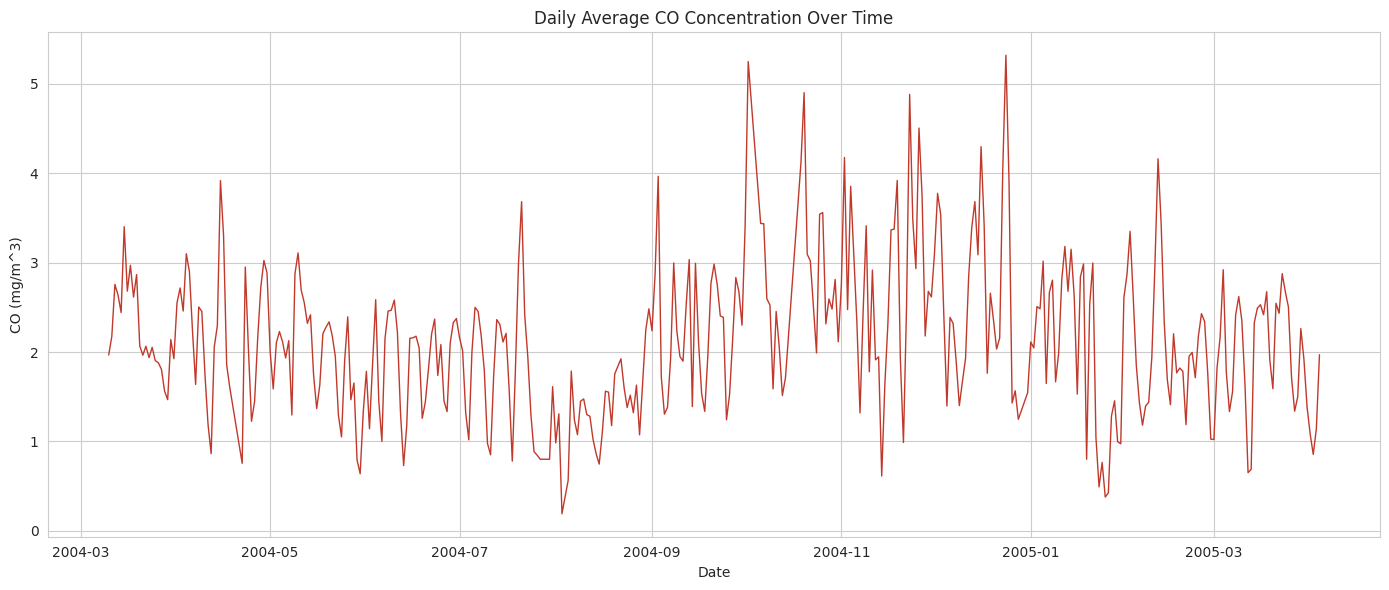

In [8]:
daily_co = df.set_index('DateTime')['CO(GT)'].resample('D').mean()

plt.figure(figsize=(14, 6))
plt.plot(daily_co.index, daily_co.values, color='#c0392b', linewidth=1)
plt.title('Daily Average CO Concentration Over Time')
plt.xlabel('Date')
plt.ylabel('CO (mg/m^3)')
plt.tight_layout()
plt.show()

## 5. NOx and NO2 Trends Over Time

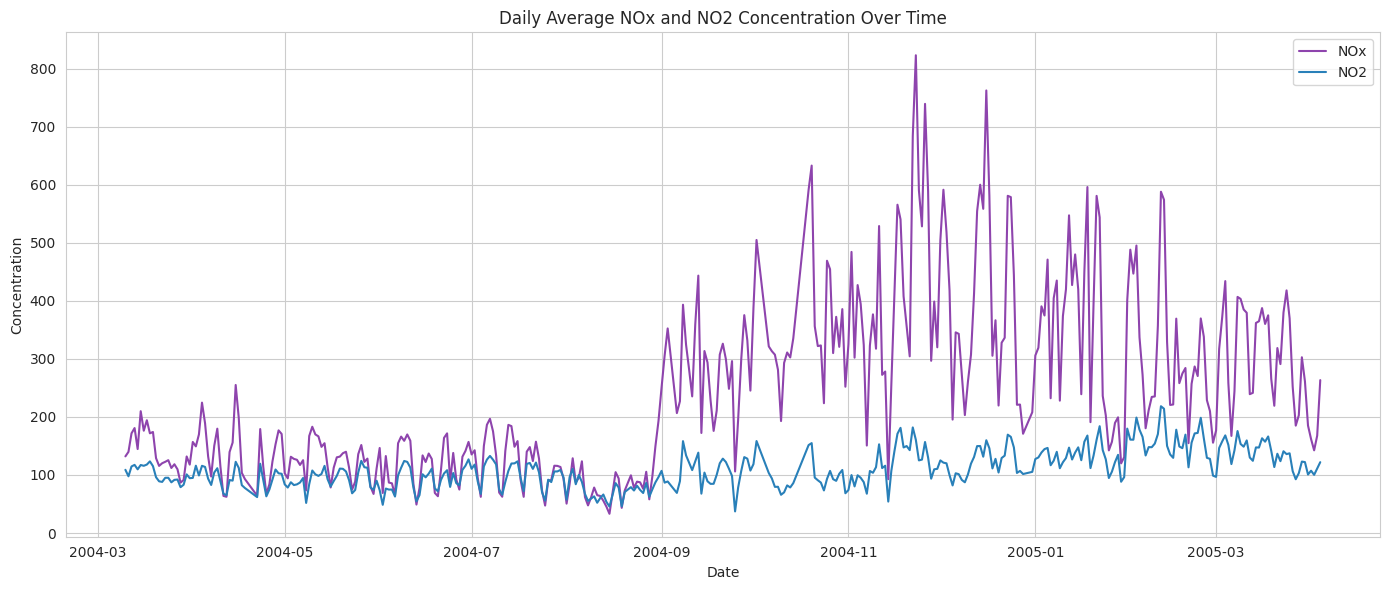

In [9]:
daily_pollutants = df.set_index('DateTime')[['NOx(GT)', 'NO2(GT)']].resample('D').mean()

plt.figure(figsize=(14, 6))
plt.plot(daily_pollutants.index, daily_pollutants['NOx(GT)'], label='NOx', color='#8e44ad')
plt.plot(daily_pollutants.index, daily_pollutants['NO2(GT)'], label='NO2', color='#2980b9')
plt.title('Daily Average NOx and NO2 Concentration Over Time')
plt.xlabel('Date')
plt.ylabel('Concentration')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Average Pollution Levels by Hour of Day

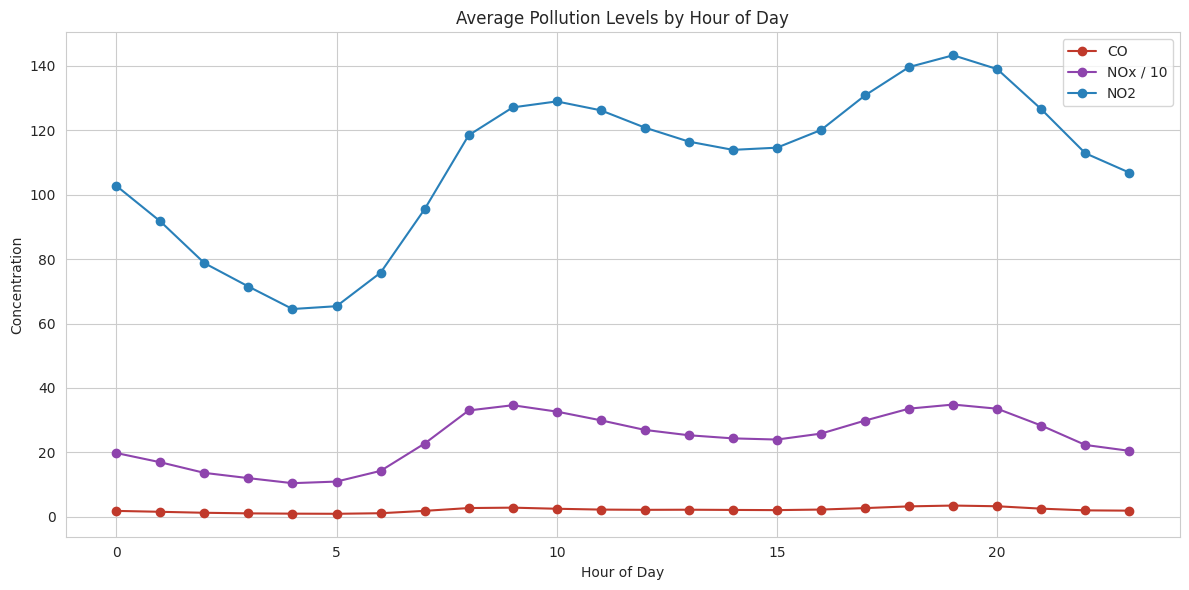

In [10]:
hourly_avg = df.groupby('Hour')[['CO(GT)', 'NOx(GT)', 'NO2(GT)']].mean()

plt.figure(figsize=(12, 6))
plt.plot(hourly_avg.index, hourly_avg['CO(GT)'], marker='o', label='CO', color='#c0392b')
plt.plot(hourly_avg.index, hourly_avg['NOx(GT)'] / 10, marker='o', label='NOx / 10', color='#8e44ad')
plt.plot(hourly_avg.index, hourly_avg['NO2(GT)'], marker='o', label='NO2', color='#2980b9')
plt.title('Average Pollution Levels by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Concentration')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Pollution Levels by Day of Week

/tmp/ipykernel_549/2358859141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_avg.index, y=weekday_avg.values, palette='Reds_d')


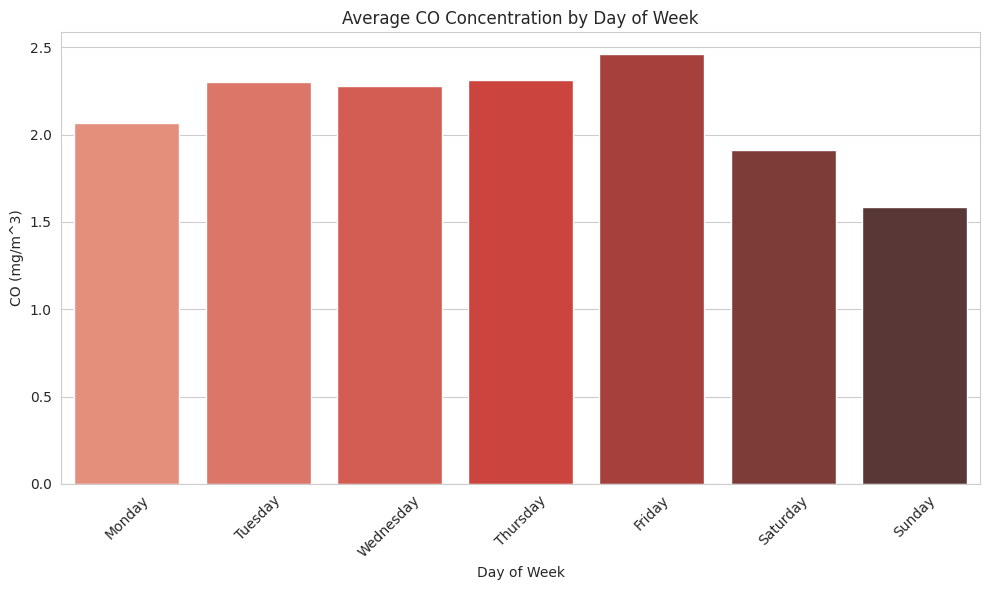

In [11]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = df.groupby('DayOfWeek')['CO(GT)'].mean().reindex(day_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=weekday_avg.index, y=weekday_avg.values, palette='Reds_d')
plt.title('Average CO Concentration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('CO (mg/m^3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Monthly Pollution Trends

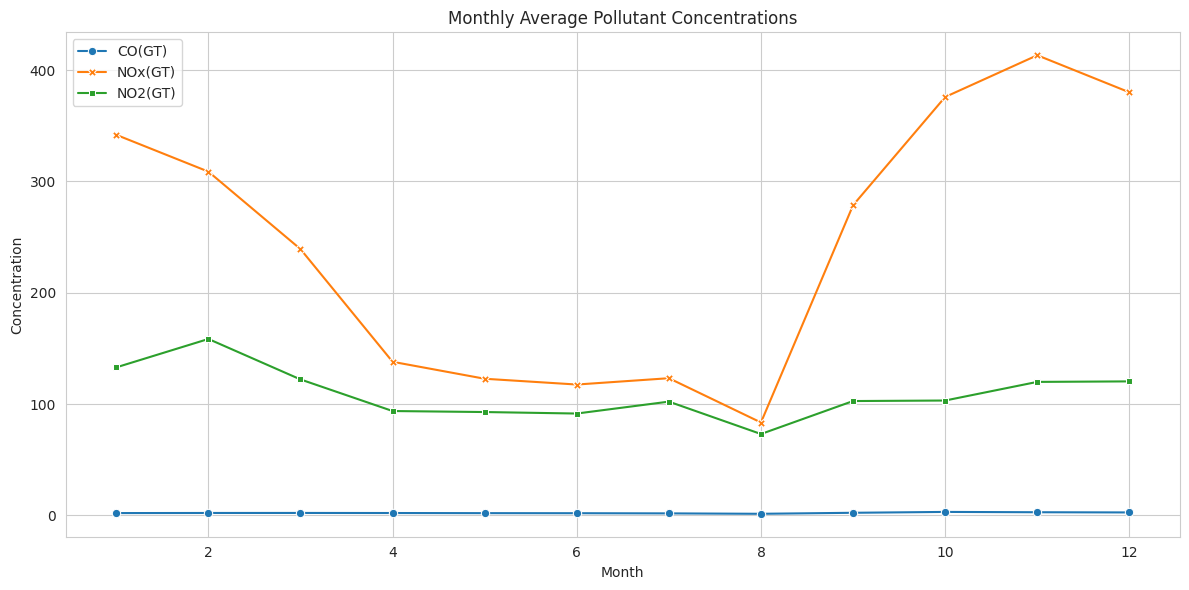

In [12]:
monthly_avg = df.groupby('Month')[['CO(GT)', 'NOx(GT)', 'NO2(GT)']].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_avg, markers=True, dashes=False)
plt.title('Monthly Average Pollutant Concentrations')
plt.xlabel('Month')
plt.ylabel('Concentration')
plt.tight_layout()
plt.show()

## 9. Temperature vs CO Concentration

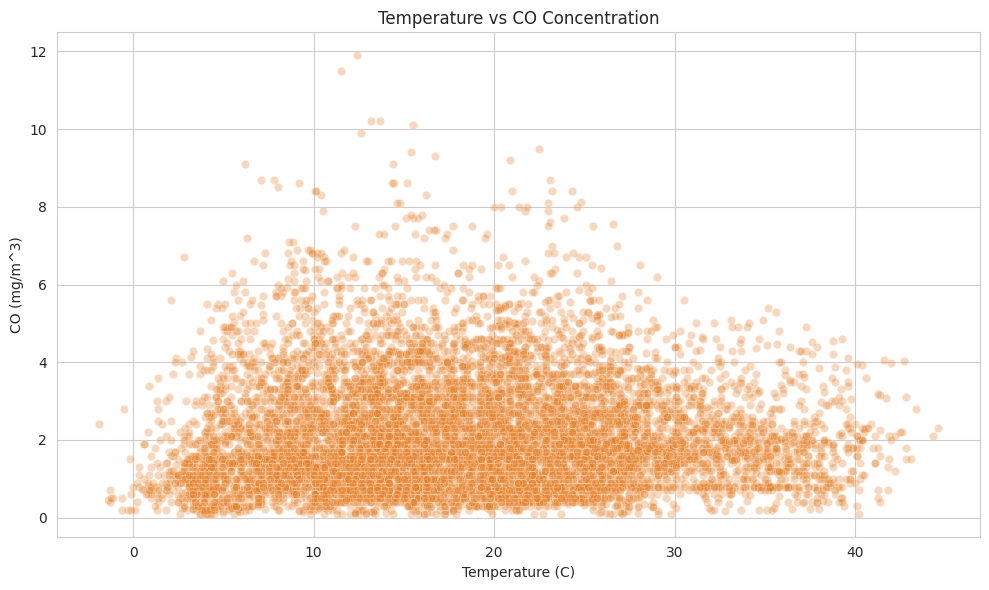

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='T', y='CO(GT)', alpha=0.3, color='#e67e22')
plt.title('Temperature vs CO Concentration')
plt.xlabel('Temperature (C)')
plt.ylabel('CO (mg/m^3)')
plt.tight_layout()
plt.show()

## 10. Relative Humidity vs Pollutant Levels

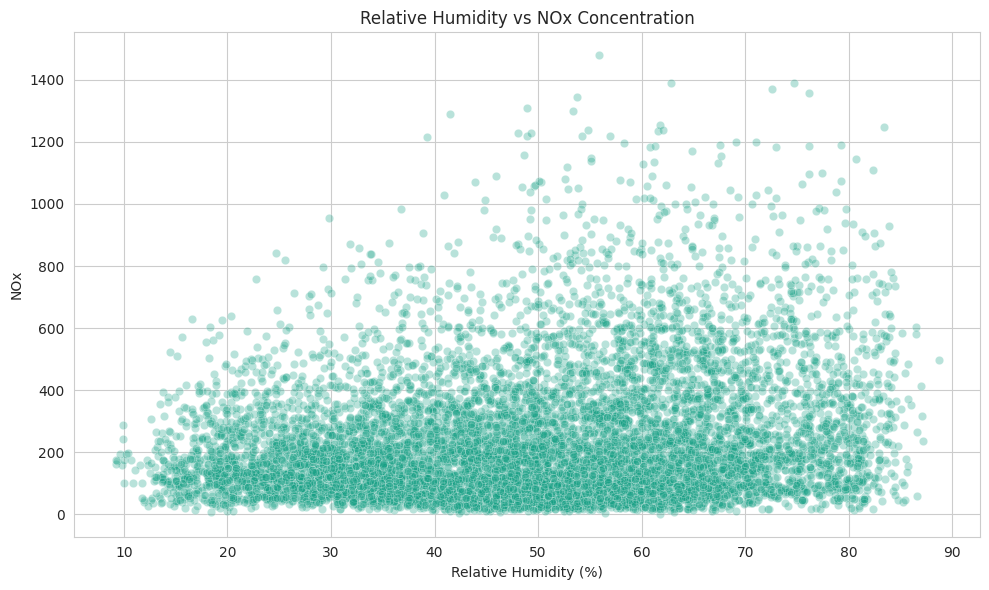

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='RH', y='NOx(GT)', alpha=0.3, color='#16a085')
plt.title('Relative Humidity vs NOx Concentration')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('NOx')
plt.tight_layout()
plt.show()

## 11. Correlation Between Pollutants and Weather

In [15]:
corr_cols = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH', 'AH']
corr = df[corr_cols].corr()
corr

,CO(GT),C6H6(GT),NOx(GT),NO2(GT),T,RH,AH
CO(GT),1.000000,0.833991,0.791272,0.675804,0.018899,0.062650,0.060264
C6H6(GT),0.833991,1.000000,0.667005,0.581387,0.198956,-0.061681,0.167972
NOx(GT),0.791272,0.667005,1.000000,0.763038,-0.246280,0.212168,-0.122630
NO2(GT),0.675804,0.581387,0.763038,1.000000,-0.194418,-0.077801,-0.322243
T,0.018899,0.198956,-0.246280,-0.194418,1.000000,-0.574466,0.658761
RH,0.062650,-0.061681,0.212168,-0.077801,-0.574466,1.000000,0.170529
AH,0.060264,0.167972,-0.122630,-0.322243,0.658761,0.170529,1.000000


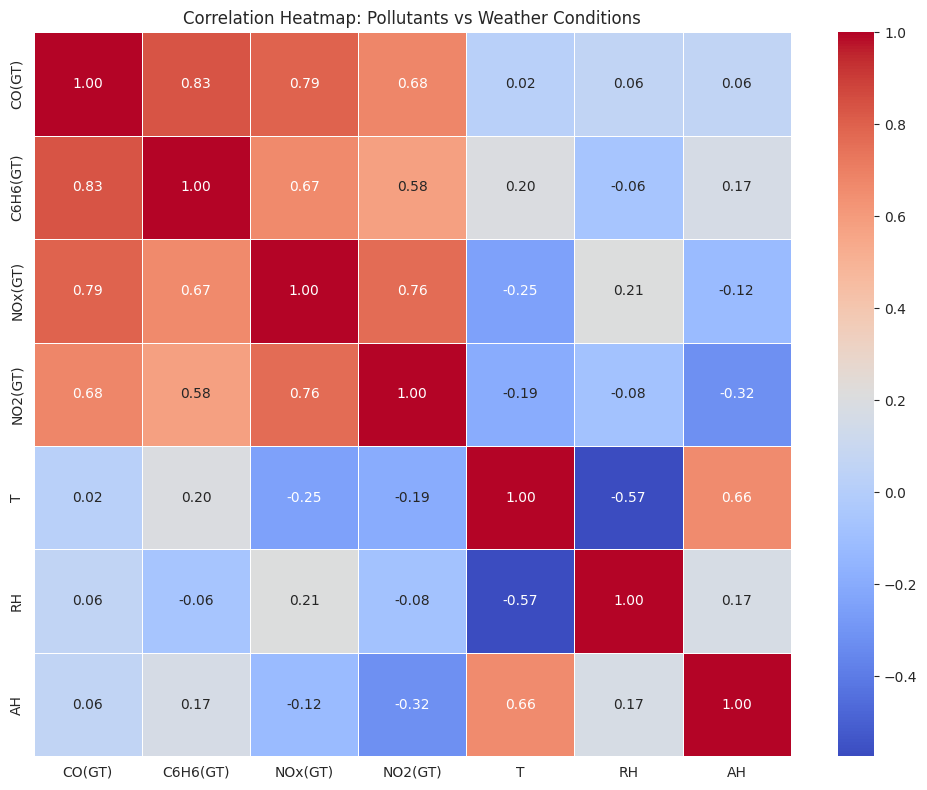

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Pollutants vs Weather Conditions')
plt.tight_layout()
plt.show()

## 12. Distribution of Key Pollutants

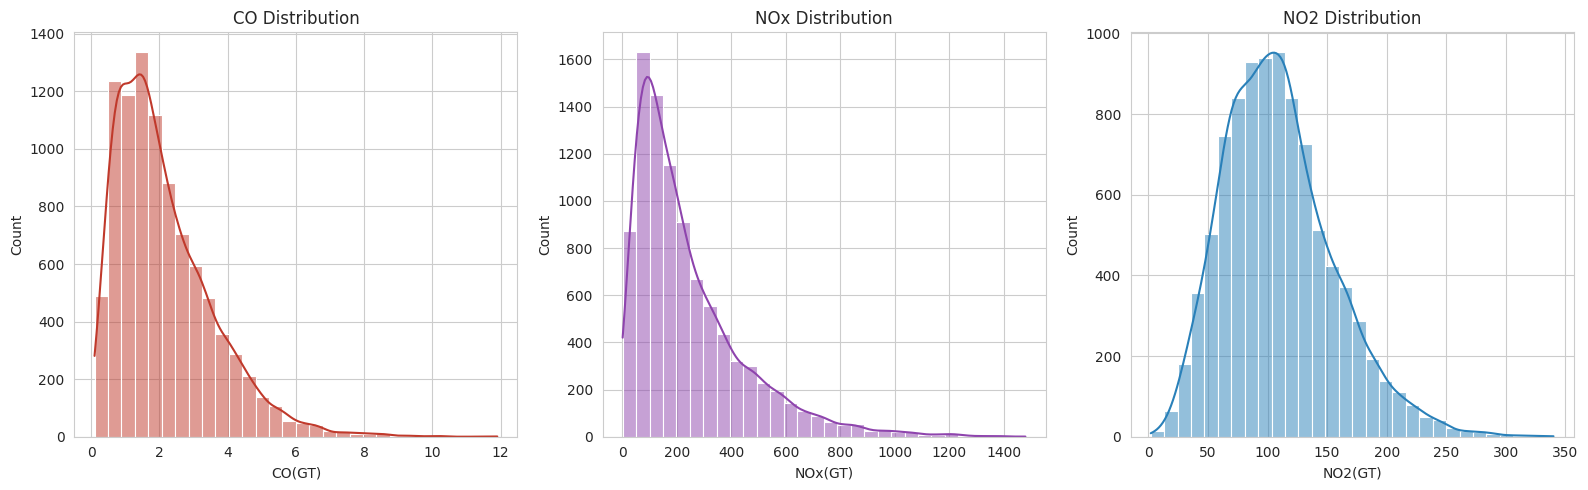

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(df['CO(GT)'].dropna(), bins=30, kde=True, ax=axes[0], color='#c0392b')
axes[0].set_title('CO Distribution')

sns.histplot(df['NOx(GT)'].dropna(), bins=30, kde=True, ax=axes[1], color='#8e44ad')
axes[1].set_title('NOx Distribution')

sns.histplot(df['NO2(GT)'].dropna(), bins=30, kde=True, ax=axes[2], color='#2980b9')
axes[2].set_title('NO2 Distribution')

plt.tight_layout()
plt.show()

## 13. Benzene (C6H6) Levels Over Time

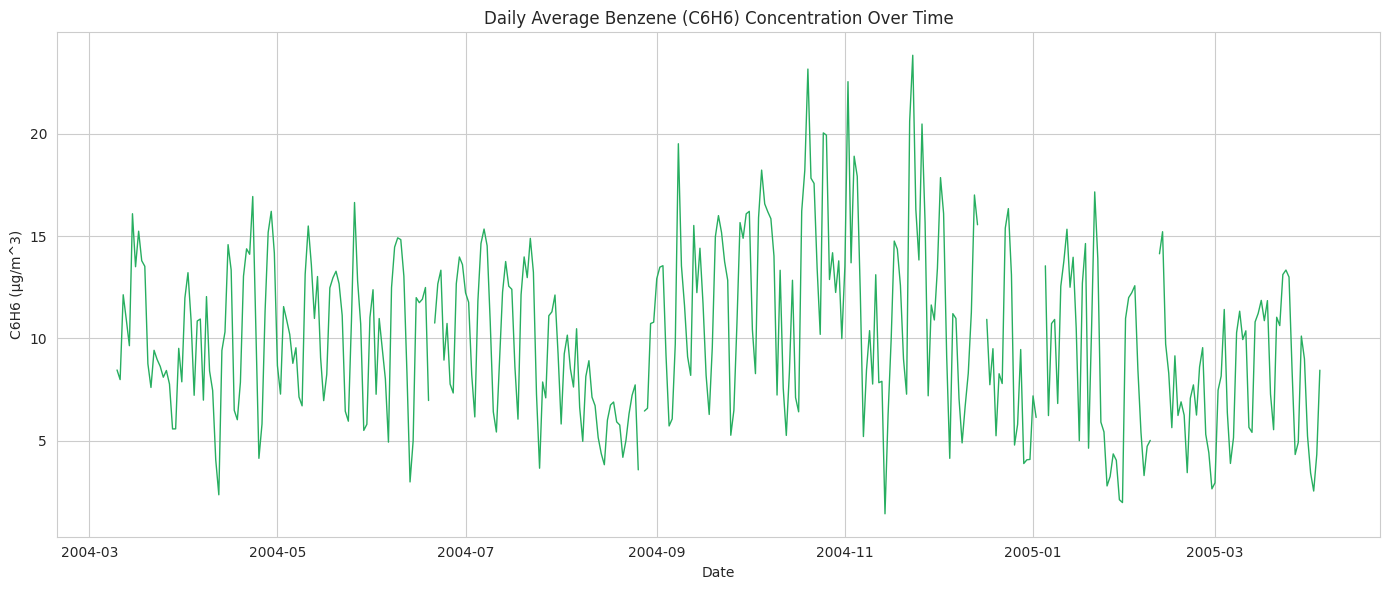

In [18]:
daily_benzene = df.set_index('DateTime')['C6H6(GT)'].resample('D').mean()

plt.figure(figsize=(14, 6))
plt.plot(daily_benzene.index, daily_benzene.values, color='#27ae60', linewidth=1)
plt.title('Daily Average Benzene (C6H6) Concentration Over Time')
plt.xlabel('Date')
plt.ylabel('C6H6 (µg/m^3)')
plt.tight_layout()
plt.show()

## 14. Pairwise Relationships Between Pollutants and Weather

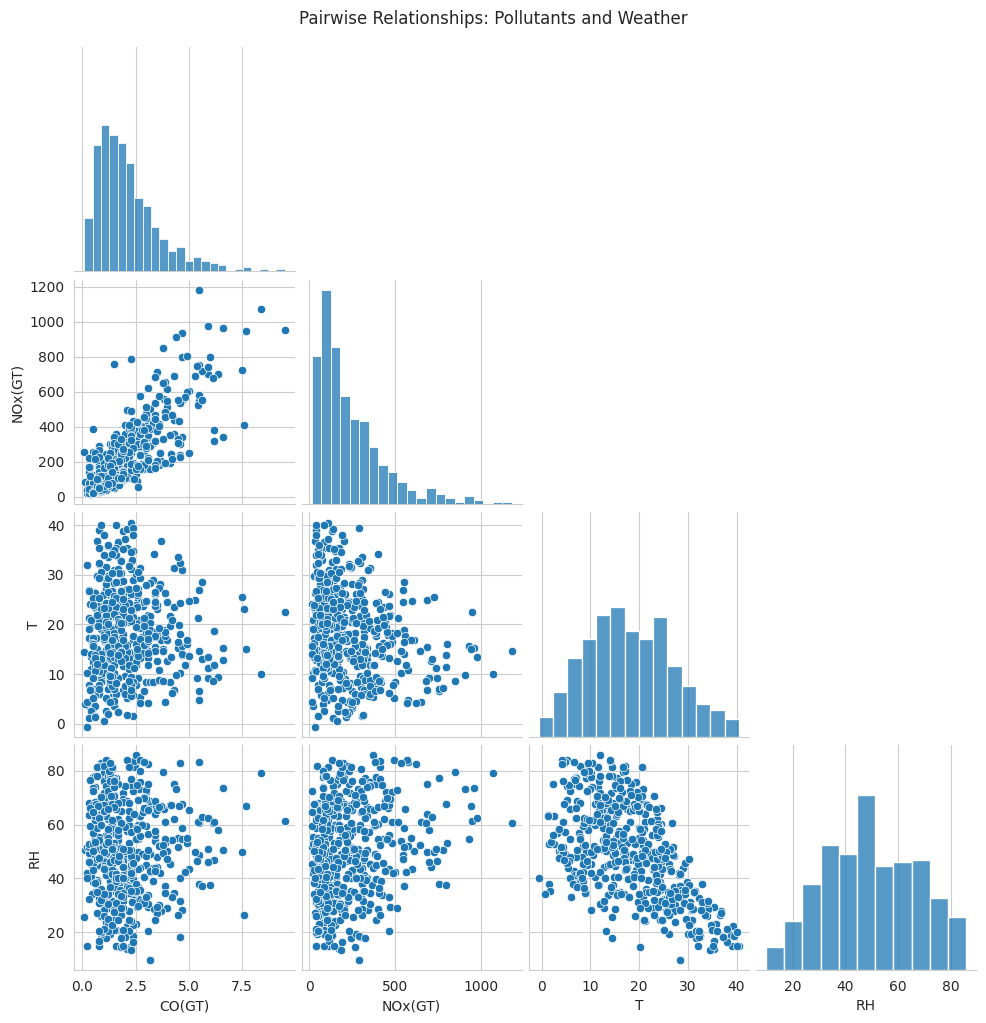

In [19]:
sns.pairplot(df[['CO(GT)', 'NOx(GT)', 'T', 'RH']].dropna().sample(500, random_state=42), corner=True)
plt.suptitle('Pairwise Relationships: Pollutants and Weather', y=1.02)
plt.show()